In [3]:
import os
import statistics
import time
from dataclasses import dataclass, field
from typing import Optional

import httpx
import matplotlib.pyplot as plt
import pandas as pd
from rich.console import Console
from rich.table import Table

BASE_URL = os.getenv("LITELLM_URL", "http://localhost/v1")
API_KEY = os.getenv("LITELLM_MASTER_KEY", "sk-research-local-1234")
MODEL = os.getenv("LITELLM_MODEL", "qwen3")

console = Console()


@dataclass
class Result:
    prompt: str
    latency_ms: float
    cache_hit: Optional[str]
    response_preview: str
    group: str = ""


@dataclass
class ExperimentGroup:
    name: str
    description: str
    prompts: list[str]
    results: list[Result] = field(default_factory=list)


def send_prompt(prompt: str, group: str = "") -> Result:
    """Send a completion request and capture latency plus cache headers."""
    start = time.perf_counter()

    with httpx.Client(base_url=BASE_URL, timeout=120) as http:
        resp = http.post(
            "/chat/completions",
            headers={"Authorization": f"Bearer {API_KEY}"},
            json={
                "model": MODEL,
                "messages": [{"role": "user", "content": prompt}],
                "max_tokens": 100,
            },
        )
        resp.raise_for_status()
        data = resp.json()

    latency_ms = (time.perf_counter() - start) * 1000
    cache_hit = resp.headers.get("x-litellm-cache-hit") or resp.headers.get("x-cache-hit")
    content = data["choices"][0]["message"]["content"]

    return Result(
        prompt=prompt,
        latency_ms=latency_ms,
        cache_hit=cache_hit,
        response_preview=content[:80].replace("\n", " "),
        group=group,
    )

In [4]:
EXPERIMENTS: list[ExperimentGroup] = [
    ExperimentGroup(
        name="Exact duplicate",
        description="Same prompt sent twice - expect cache hit on second call.",
        prompts=[
            "What is the capital of France?",
            "What is the capital of France?",
        ],
    ),
    ExperimentGroup(
        name="Paraphrase (high similarity)",
        description="Semantically identical, different wording - tests similarity threshold.",
        prompts=[
            "What is the capital of France?",
            "Which city serves as the capital of France?",
            "Tell me the capital city of France.",
        ],
    ),
    ExperimentGroup(
        name="Related but distinct (medium similarity)",
        description="Same topic, different question - may or may not hit cache depending on threshold.",
        prompts=[
            "What is the capital of France?",
            "What is the population of Paris?",
            "What language is spoken in France?",
        ],
    ),
    ExperimentGroup(
        name="Unrelated (low similarity)",
        description="Completely different topics - should never hit cache.",
        prompts=[
            "What is the capital of France?",
            "How does photosynthesis work?",
            "Explain the rules of chess.",
        ],
    ),
    ExperimentGroup(
        name="Load balancing probe",
        description="10 identical requests to observe load balancing across Ollama instances.",
        prompts=["Say hello in one word."] * 10,
    ),
]

In [6]:
def run_experiments() -> list[Result]:
    all_results: list[Result] = []

    for experiment in EXPERIMENTS:
        console.rule(f"[bold]{experiment.name}")
        console.print(f"[dim]{experiment.description}[/dim]\n")

        for i, prompt in enumerate(experiment.prompts):
            label = f"  [{i+1}/{len(experiment.prompts)}] {prompt[:60]}..."
            console.print(label, end="")

            result = send_prompt(prompt, group=experiment.name)
            experiment.results.append(result)
            all_results.append(result)

            hit_tag = "[green]HIT[/green]" if result.cache_hit == "True" else "[yellow]MISS[/yellow]" if result.cache_hit == "False" else "[dim]?[/dim]"
            console.print(f"  {hit_tag}  {result.latency_ms:7.0f} ms")

        console.print()

    return all_results


def print_summary(results: list[Result]) -> None:
    console.rule("[bold]Summary")

    table = Table(show_header=True, header_style="bold")
    table.add_column("Group", style="dim", width=28)
    table.add_column("Prompt", width=38)
    table.add_column("Cache", justify="center", width=6)
    table.add_column("Latency (ms)", justify="right", width=13)

    for result in results:
        hit_str = "✓" if result.cache_hit == "True" else "✗" if result.cache_hit == "False" else "?"
        hit_style = "green" if result.cache_hit == "True" else "yellow" if result.cache_hit == "False" else "dim"
        table.add_row(
            result.group,
            result.prompt[:36] + "..." if len(result.prompt) > 36 else result.prompt,
            f"[{hit_style}]{hit_str}[/{hit_style}]",
            f"{result.latency_ms:.0f}",
        )

    console.print(table)

    hits = [result.latency_ms for result in results if result.cache_hit == "True"]
    misses = [result.latency_ms for result in results if result.cache_hit == "False"]

    console.print()
    if hits:
        console.print(
            f"[green]Cache HIT  [/green] avg={statistics.mean(hits):.0f} ms  "
            f"median={statistics.median(hits):.0f} ms  n={len(hits)}"
        )
    if misses:
        console.print(
            f"[yellow]Cache MISS [/yellow] avg={statistics.mean(misses):.0f} ms  "
            f"median={statistics.median(misses):.0f} ms  n={len(misses)}"
        )
    if hits and misses:
        speedup = statistics.mean(misses) / statistics.mean(hits)
        console.print(f"\n[bold]Cache speedup: {speedup:.1f}×[/bold]")


all_results = run_experiments()
print_summary(all_results)
results_df = pd.DataFrame(
    [
        {
            "group": result.group,
            "prompt": result.prompt,
            "cache_hit": result.cache_hit,
            "latency_ms": result.latency_ms,
            "response_preview": result.response_preview,
        }
        for result in all_results
    ]
)

display(results_df)

───────────────────────────────────────────────── Exact duplicate ─────────────────────────────────────────────────

Same prompt sent twice - expect cache hit on second call.

[1/2] What is the capital of France?...

?      404 ms

[2/2] What is the capital of France?...

...

[10/10] Say hello in one word....

?      120 ms

───────────────────────────────────────────────────── Summary ─────────────────────────────────────────────────────

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Group                        ┃ Prompt                                 ┃ Cache  ┃  Latency (ms) ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Exact duplicate              │ What is the capital of France?         │   ?    │           404 │
│ Exact duplicate              │ What is the capital of France?         │   ?    │            38 │
│ Paraphrase (high similarity) │ What is the capital of France?         │   ?    │            48 │
│ Paraphrase (high similarity) │ Which city serves as the capital of    │   ?    │            47 │
│                              │ ...                                    │        │               │
│ Paraphrase (high similarity) │ Tell me the capital city of France.    │   ?    │            41 │
│ Related but distinct (medium │ What is the capital of France?         │   ?    │            41 │
│ similarity)                  │                                        │        │               │
│ Related but distinct (medium │ What is the population of Paris?       │   ?    │            85 │
│ similarity)                  │                                        │        │               │
│ Related but distinct (medium │ What language is spoken in France?     │   ?    │            54 │
│ similarity)                  │                                        │        │               │
│ Unrelated (low similarity)   │ What is the capital of France?         │   ?    │            48 │
│ Unrelated (low similarity)   │ How does photosynthesis work?          │   ?    │            47 │
│ Unrelated (low similarity)   │ Explain the rules of chess.            │   ?    │            46 │
│ Load balancing probe         │ Say hello in one word.                 │   ?    │            50 │
│ Load balancing probe         │ Say hello in one word.                 │   ?    │            52 │
│ Load balancing probe         │ Say hello in one word.                 │   ?    │            57 │
│ Load balancing probe         │ Say hello in one word.                 │   ?    │            60 │
│ Load balancing probe         │ Say hello in one word.                 │   ?    │            70 │
│ Load balancing probe         │ Say hello in one word.                 │   ?    │            86 │
│ Load balancing probe         │ Say hello in one word.                 │   ?    │           107 │
│ Load balancing probe         │ Say hello in one word.                 │   ?    │           117 │
│ Load balancing probe         │ Say hello in one word.                 │   ?    │           115 │
│ Load balancing probe         │ Say hello in one word.                 │   ?    │           120 │
└──────────────────────────────┴────────────────────────────────────────┴────────┴───────────────┘

,group,prompt,cache_hit,latency_ms,response_preview
0,Exact duplicate,What is the capital of France?,None,403.668067,
1,Exact duplicate,What is the capital of France?,None,38.297696,
2,Paraphrase (high similarity),What is the capital of France?,None,47.633851,
3,Paraphrase (high similarity),Which city serves as the capital of France?,None,46.989253,
4,Paraphrase (high similarity),Tell me the capital city of France.,None,41.290384,
5,Related but distinct (medium similarity),What is the capital of France?,None,40.559504,
6,Related but distinct (medium similarity),What is the population of Paris?,None,84.885236,
7,Related but distinct (medium similarity),What language is spoken in France?,None,53.837115,
8,Unrelated (low similarity),What is the capital of France?,None,48.308605,
9,Unrelated (low similarity),How does photosynthesis work?,None,46.587350,


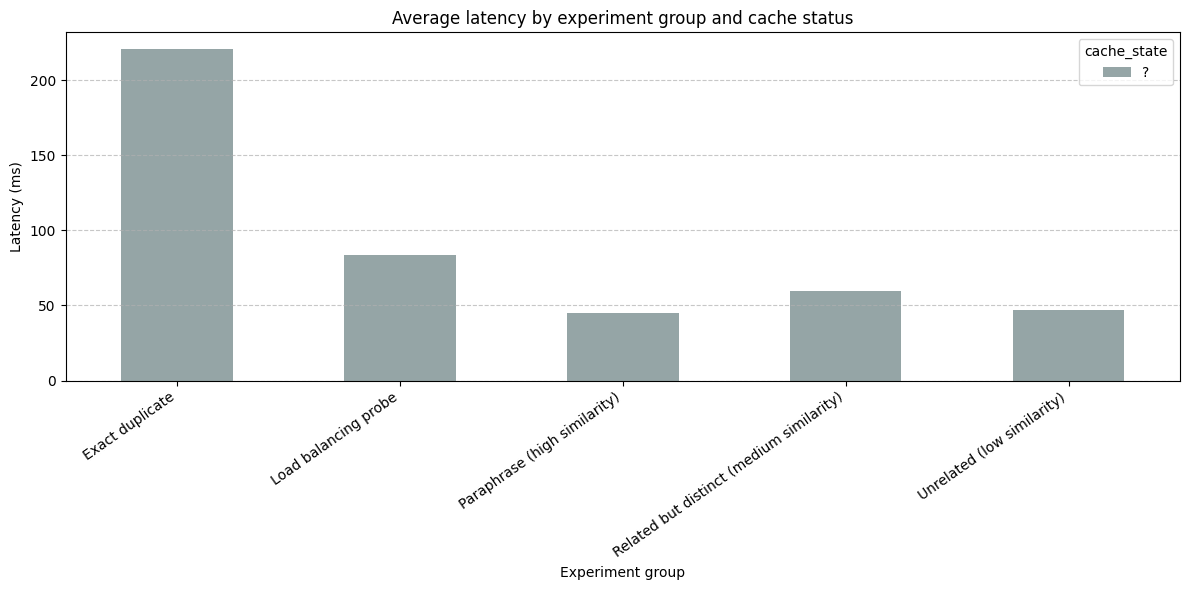

In [7]:
if not results_df.empty:
    plot_df = results_df.copy()
    plot_df["cache_state"] = plot_df["cache_hit"].fillna("?").map({"True": "HIT", "False": "MISS"}).fillna("?")
    group_summary = plot_df.groupby(["group", "cache_state"])["latency_ms"].mean().unstack(fill_value=0)
    ordered_columns = [column for column in ["HIT", "MISS", "?"] if column in group_summary.columns]
    group_summary = group_summary[ordered_columns]

    colors = ["#2ecc71" if column == "HIT" else "#e74c3c" if column == "MISS" else "#95a5a6" for column in group_summary.columns]
    ax = group_summary.plot(kind="bar", figsize=(12, 6), color=colors)
    ax.set_title("Average latency by experiment group and cache status")
    ax.set_ylabel("Latency (ms)")
    ax.set_xlabel("Experiment group")
    ax.grid(axis="y", linestyle="--", alpha=0.7)
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()